In [ ]:
from src.auth import AuthenticationService
from src.ndvi import extract_ndvi
from src.canopy_height import extract_canopy_height
from src.elevation import extract_elevation
from src.landcover import extract_landcover
from src.worldclim import extract_worldclim
from src.aoi import create_aoi_from_coordinates
from src.utils import plot_map, plot_images
from src.sampling import clean_coordinates_dataframe, convert_points_to_buffered_features
import pandas as pd

In [2]:
ok = AuthenticationService.authenticate(project_id="wildmon-projects")
if not ok:
    raise SystemExit("Could not initialize EE")

✅ Google Earth Engine initialized


In [ ]:
df = pd.read_csv("./input/configuration.csv")

df = clean_coordinates_dataframe(df, lat_col="latitude", lon_col="longitude")
points_fc = convert_points_to_buffered_features(df, lat_col="latitude", lon_col="longitude", buffer_meters=200)

2025-11-18 16:26:46,963 - INFO - Successfully validated and cleaned 40 points.


2025-11-18 16:26:47,548 - INFO - Creating map plot for 40 features...
2025-11-18 16:26:48,683 - INFO - Added basemap: satellite
2025-11-18 16:26:48,703 - INFO - Map plot created successfully


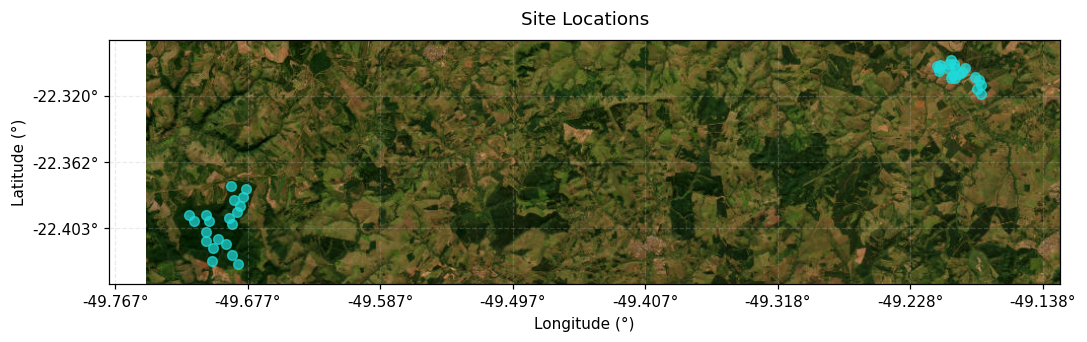

In [4]:
fig, ax = plot_map(df, 
                   basemap='satellite', 
                   alpha=0.7, 
                   color="#1FDBDB", 
                   buffer_pct=0.1,
                   title="Site Locations")  

In [5]:
aoi = create_aoi_from_coordinates(df, buffer_km=30)

📍 AOI Bounds: Lat[-22.6956, -22.0278], Lon[-50.0092, -48.8880]
📊 Defined study area for 40 points with 30km margin.


In [ ]:
# Process NDVI
df, image_ndvi = extract_ndvi(
    df=df,
    aoi=aoi,
    points_feature_collection=points_fc,
    start_date="2021-11-01",
    end_date="2024-12-31",
    scale=30,
    mask_water=True
)

2025-11-18 09:30:08,648 - INFO - Processing 40 points...
2025-11-18 09:30:08,648 - INFO - Date range: 2021-11-01 to 2024-12-31
2025-11-18 09:30:08,648 - INFO - Buffer: 200m, Scale: 30m
2025-11-18 09:30:08,648 - INFO - Water masking: True
2025-11-18 09:30:08,649 - INFO - Creating Landsat composite for study area...
2025-11-18 09:30:08,849 - INFO - Found 183 Landsat 9 images for study area
2025-11-18 09:30:08,850 - INFO - Loading GLCF water mask...
2025-11-18 09:30:08,852 - INFO - Preparing points for batch processing...
2025-11-18 09:30:08,852 - INFO - Extracting NDVI statistics (batch operation)...
2025-11-18 09:30:08,855 - INFO - Fetching results from Earth Engine...
2025-11-18 09:30:09,198 - INFO - Parsing results...
2025-11-18 09:30:09,200 - INFO - Successfully processed 40/40 points
2025-11-18 09:30:09,200 - INFO - NDVI range: 0.371 to 0.901
2025-11-18 09:30:09,200 - INFO - NDVI mean: 0.831 ± 0.115


In [7]:
df

,site_name,latitude,longitude,filename_offset_hours,folders,tags,NDVI_mean,NDVI_std
0,Caetetus-P01,-22.394977,-49.717152,0,Sao-Paulo/Caetetus-P01,NaN,0.890257,0.007802
1,Caetetus-P02,-22.398559,-49.713233,0,Sao-Paulo/Caetetus-P02,NaN,0.892297,0.010076
2,Caetetus-P03,-22.394884,-49.705497,0,Sao-Paulo/Caetetus-P03,NaN,0.884116,0.005713
3,Caetetus-P04,-22.405722,-49.705396,0,Sao-Paulo/Caetetus-P04,NaN,0.897045,0.005600
4,Caetetus-P05,-22.411141,-49.705346,0,Sao-Paulo/Caetetus-P05,NaN,0.901239,0.006832
5,Caetetus-P06,-22.398481,-49.703521,0,Sao-Paulo/Caetetus-P06,NaN,0.884727,0.005503
6,Caetetus-P07,-22.415340,-49.700660,0,Sao-Paulo/Caetetus-P07,NaN,0.897535,0.007030
7,Caetetus-P08,-22.423755,-49.701343,0,Sao-Paulo/Caetetus-P08,NaN,0.879454,0.022532
8,Caetetus-P09,-22.396565,-49.689940,0,Sao-Paulo/Caetetus-P09,NaN,0.877235,0.006834
9,Caetetus-P10,-22.400162,-49.687963,0,Sao-Paulo/Caetetus-P10,NaN,0.882283,0.006541


In [8]:
df, image_elevation = extract_elevation(df)

Processing 40 points...
🔄 Waiting for Earth Engine response...
✅ Elevation and slope statistics extracted (SRTM90_V4)!


In [9]:
df

,site_name,latitude,longitude,filename_offset_hours,folders,tags,NDVI_mean,NDVI_std,elevation_mean,elevation_std,slope_mean,slope_std
0,Caetetus-P01,-22.394977,-49.717152,0,Sao-Paulo/Caetetus-P01,NaN,0.890257,0.007802,573.456825,21.349019,10.876475,4.735555
1,Caetetus-P02,-22.398559,-49.713233,0,Sao-Paulo/Caetetus-P02,NaN,0.892297,0.010076,561.459504,19.317308,9.151536,4.418261
2,Caetetus-P03,-22.394884,-49.705497,0,Sao-Paulo/Caetetus-P03,NaN,0.884116,0.005713,657.833333,2.820850,1.498646,0.975294
3,Caetetus-P04,-22.405722,-49.705396,0,Sao-Paulo/Caetetus-P04,NaN,0.897045,0.005600,574.417198,12.824948,5.529233,1.701098
4,Caetetus-P05,-22.411141,-49.705346,0,Sao-Paulo/Caetetus-P05,NaN,0.901239,0.006832,551.590877,14.585447,6.227223,1.461215
5,Caetetus-P06,-22.398481,-49.703521,0,Sao-Paulo/Caetetus-P06,NaN,0.884727,0.005503,647.259032,7.057688,4.504498,2.064384
6,Caetetus-P07,-22.415340,-49.700660,0,Sao-Paulo/Caetetus-P07,NaN,0.897535,0.007030,567.846118,7.929215,3.465041,1.280166
7,Caetetus-P08,-22.423755,-49.701343,0,Sao-Paulo/Caetetus-P08,NaN,0.879454,0.022532,517.551333,8.974075,5.398058,2.241363
8,Caetetus-P09,-22.396565,-49.689940,0,Sao-Paulo/Caetetus-P09,NaN,0.877235,0.006834,651.768140,7.346416,3.347554,2.340717
9,Caetetus-P10,-22.400162,-49.687963,0,Sao-Paulo/Caetetus-P10,NaN,0.882283,0.006541,647.753425,12.472301,6.139242,3.943104


In [10]:
df, image_canopy_height = extract_canopy_height(df)

📦 Processing 40 points in 1 batches of 50...
  ✅ Batch 1 processed (1-40)


In [11]:
df

,site_name,latitude,longitude,filename_offset_hours,folders,tags,NDVI_mean,NDVI_std,elevation_mean,elevation_std,slope_mean,slope_std,canopy_height_mean,canopy_height_std
0,Caetetus-P01,-22.394977,-49.717152,0,Sao-Paulo/Caetetus-P01,NaN,0.890257,0.007802,573.456825,21.349019,10.876475,4.735555,24.002387,1.977494
1,Caetetus-P02,-22.398559,-49.713233,0,Sao-Paulo/Caetetus-P02,NaN,0.892297,0.010076,561.459504,19.317308,9.151536,4.418261,24.314889,1.498289
2,Caetetus-P03,-22.394884,-49.705497,0,Sao-Paulo/Caetetus-P03,NaN,0.884116,0.005713,657.833333,2.820850,1.498646,0.975294,20.190000,1.084889
3,Caetetus-P04,-22.405722,-49.705396,0,Sao-Paulo/Caetetus-P04,NaN,0.897045,0.005600,574.417198,12.824948,5.529233,1.701098,24.765308,1.222912
4,Caetetus-P05,-22.411141,-49.705346,0,Sao-Paulo/Caetetus-P05,NaN,0.901239,0.006832,551.590877,14.585447,6.227223,1.461215,25.284308,1.155847
5,Caetetus-P06,-22.398481,-49.703521,0,Sao-Paulo/Caetetus-P06,NaN,0.884727,0.005503,647.259032,7.057688,4.504498,2.064384,20.720994,1.171250
6,Caetetus-P07,-22.415340,-49.700660,0,Sao-Paulo/Caetetus-P07,NaN,0.897535,0.007030,567.846118,7.929215,3.465041,1.280166,23.404110,1.571882
7,Caetetus-P08,-22.423755,-49.701343,0,Sao-Paulo/Caetetus-P08,NaN,0.879454,0.022532,517.551333,8.974075,5.398058,2.241363,21.326855,1.419026
8,Caetetus-P09,-22.396565,-49.689940,0,Sao-Paulo/Caetetus-P09,NaN,0.877235,0.006834,651.768140,7.346416,3.347554,2.340717,20.186357,0.811844
9,Caetetus-P10,-22.400162,-49.687963,0,Sao-Paulo/Caetetus-P10,NaN,0.882283,0.006541,647.753425,12.472301,6.139242,3.943104,20.219429,0.752806


In [12]:
df = extract_worldclim(df)

2025-11-18 09:30:09,820 - INFO - Processing 40 points...
2025-11-18 09:30:09,821 - INFO - Variables: bio01, bio02, bio03, bio04, bio05, bio06, bio07, bio08, bio09, bio10, bio11, bio12, bio13, bio14, bio15, bio16, bio17, bio18, bio19
2025-11-18 09:30:09,821 - INFO - Buffer: 200m, Scale: 1000m
2025-11-18 09:30:09,821 - INFO - Preparing WorldClim image...
2025-11-18 09:30:09,822 - INFO - Preparing points for batch processing...
2025-11-18 09:30:09,824 - INFO - Extracting bioclimatic variables (batch operation)...
2025-11-18 09:30:09,830 - INFO - Fetching results from Earth Engine...
2025-11-18 09:30:13,158 - INFO - Parsing results...
2025-11-18 09:30:13,171 - INFO - Successfully processed 40/40 points
2025-11-18 09:30:13,172 - INFO - Annual Mean Temperature (bio01): 19.9°C to 21.2°C (mean: 20.7°C)
2025-11-18 09:30:13,172 - INFO - Annual Precipitation (bio12): 1198mm to 1307mm (mean: 1248mm)


In [13]:
df

,site_name,latitude,longitude,filename_offset_hours,folders,tags,NDVI_mean,NDVI_std,elevation_mean,elevation_std,...,bio15_mean,bio15_stdDev,bio16_mean,bio16_stdDev,bio17_mean,bio17_stdDev,bio18_mean,bio18_stdDev,bio19_mean,bio19_stdDev
0,Caetetus-P01,-22.394977,-49.717152,0,Sao-Paulo/Caetetus-P01,NaN,0.890257,0.007802,573.456825,21.349019,...,58.571429,0.500000,605.000000,0.000000,126.000000,0.000000,605.000000,0.000000,148.428571,0.500000
1,Caetetus-P02,-22.398559,-49.713233,0,Sao-Paulo/Caetetus-P02,NaN,0.892297,0.010076,561.459504,19.317308,...,59.000000,0.000000,599.000000,0.000000,128.000000,0.000000,599.000000,0.000000,149.000000,0.000000
2,Caetetus-P03,-22.394884,-49.705497,0,Sao-Paulo/Caetetus-P03,NaN,0.884116,0.005713,657.833333,2.820850,...,59.000000,0.000000,607.000000,0.000000,124.000000,0.000000,607.000000,0.000000,147.000000,0.000000
3,Caetetus-P04,-22.405722,-49.705396,0,Sao-Paulo/Caetetus-P04,NaN,0.897045,0.005600,574.417198,12.824948,...,58.685714,0.500000,600.371429,1.000000,127.314286,0.500000,600.371429,1.000000,149.000000,0.000000
4,Caetetus-P05,-22.411141,-49.705346,0,Sao-Paulo/Caetetus-P05,NaN,0.901239,0.006832,551.590877,14.585447,...,58.000000,0.000000,599.000000,0.000000,128.000000,0.000000,599.000000,0.000000,149.000000,0.000000
5,Caetetus-P06,-22.398481,-49.703521,0,Sao-Paulo/Caetetus-P06,NaN,0.884727,0.005503,647.259032,7.057688,...,59.000000,0.000000,601.000000,0.000000,127.000000,0.000000,601.000000,0.000000,149.000000,0.000000
6,Caetetus-P07,-22.415340,-49.700660,0,Sao-Paulo/Caetetus-P07,NaN,0.897535,0.007030,567.846118,7.929215,...,58.000000,0.000000,596.437500,1.658312,128.000000,0.000000,596.437500,1.658312,149.000000,0.000000
7,Caetetus-P08,-22.423755,-49.701343,0,Sao-Paulo/Caetetus-P08,NaN,0.879454,0.022532,517.551333,8.974075,...,58.000000,0.000000,594.029412,1.500000,128.000000,0.000000,594.029412,1.500000,149.000000,0.000000
8,Caetetus-P09,-22.396565,-49.689940,0,Sao-Paulo/Caetetus-P09,NaN,0.877235,0.006834,651.768140,7.346416,...,58.909091,0.433013,603.909091,2.958040,125.181818,1.089725,603.909091,2.958040,147.636364,0.707107
9,Caetetus-P10,-22.400162,-49.687963,0,Sao-Paulo/Caetetus-P10,NaN,0.882283,0.006541,647.753425,12.472301,...,59.000000,0.000000,603.000000,0.000000,126.000000,0.000000,603.000000,0.000000,148.000000,0.000000


In [14]:
df, image_worldcover = extract_landcover(
    df,
    buffer_meters=500,
    start_year=2020,
    end_year=2024,
    scale=20  # Lower resolution for faster processing
)

2025-11-18 09:30:13,215 - INFO - Processing 40 points...
2025-11-18 09:30:13,216 - INFO - Time period: 2020-2024
2025-11-18 09:30:13,216 - INFO - Buffer: 500m, Scale: 20m
2025-11-18 09:30:13,216 - INFO - Loading ESA WorldCover data (2020-2024)...
2025-11-18 09:30:13,217 - INFO - Preparing points for batch processing...
2025-11-18 09:30:13,218 - INFO - Extracting landcover statistics (batch operation)...
2025-11-18 09:30:13,219 - INFO - Fetching results from Earth Engine...
2025-11-18 09:30:13,575 - INFO - Adding results to DataFrame...
2025-11-18 09:30:13,577 - INFO - Successfully processed 40/40 points
2025-11-18 09:30:13,577 - INFO - Landcover class distribution:
2025-11-18 09:30:13,577 - INFO -   Tree cover: 38 points (95.0%)
2025-11-18 09:30:13,578 - INFO -   Shrubland: 2 points (5.0%)


In [15]:
df

,site_name,latitude,longitude,filename_offset_hours,folders,tags,NDVI_mean,NDVI_std,elevation_mean,elevation_std,...,bio16_stdDev,bio17_mean,bio17_stdDev,bio18_mean,bio18_stdDev,bio19_mean,bio19_stdDev,landcover_mean,landcover_std,dominant_landcover
0,Caetetus-P01,-22.394977,-49.717152,0,Sao-Paulo/Caetetus-P01,NaN,0.890257,0.007802,573.456825,21.349019,...,0.000000,126.000000,0.000000,605.000000,0.000000,148.428571,0.500000,10.000000,0.000000,Tree cover
1,Caetetus-P02,-22.398559,-49.713233,0,Sao-Paulo/Caetetus-P02,NaN,0.892297,0.010076,561.459504,19.317308,...,0.000000,128.000000,0.000000,599.000000,0.000000,149.000000,0.000000,10.000000,0.000000,Tree cover
2,Caetetus-P03,-22.394884,-49.705497,0,Sao-Paulo/Caetetus-P03,NaN,0.884116,0.005713,657.833333,2.820850,...,0.000000,124.000000,0.000000,607.000000,0.000000,147.000000,0.000000,10.000000,0.000000,Tree cover
3,Caetetus-P04,-22.405722,-49.705396,0,Sao-Paulo/Caetetus-P04,NaN,0.897045,0.005600,574.417198,12.824948,...,1.000000,127.314286,0.500000,600.371429,1.000000,149.000000,0.000000,10.000000,0.000000,Tree cover
4,Caetetus-P05,-22.411141,-49.705346,0,Sao-Paulo/Caetetus-P05,NaN,0.901239,0.006832,551.590877,14.585447,...,0.000000,128.000000,0.000000,599.000000,0.000000,149.000000,0.000000,10.000000,0.000000,Tree cover
5,Caetetus-P06,-22.398481,-49.703521,0,Sao-Paulo/Caetetus-P06,NaN,0.884727,0.005503,647.259032,7.057688,...,0.000000,127.000000,0.000000,601.000000,0.000000,149.000000,0.000000,10.000000,0.000000,Tree cover
6,Caetetus-P07,-22.415340,-49.700660,0,Sao-Paulo/Caetetus-P07,NaN,0.897535,0.007030,567.846118,7.929215,...,1.658312,128.000000,0.000000,596.437500,1.658312,149.000000,0.000000,10.000000,0.000000,Tree cover
7,Caetetus-P08,-22.423755,-49.701343,0,Sao-Paulo/Caetetus-P08,NaN,0.879454,0.022532,517.551333,8.974075,...,1.500000,128.000000,0.000000,594.029412,1.500000,149.000000,0.000000,10.203274,2.057823,Tree cover
8,Caetetus-P09,-22.396565,-49.689940,0,Sao-Paulo/Caetetus-P09,NaN,0.877235,0.006834,651.768140,7.346416,...,2.958040,125.181818,1.089725,603.909091,2.958040,147.636364,0.707107,10.000000,0.000000,Tree cover
9,Caetetus-P10,-22.400162,-49.687963,0,Sao-Paulo/Caetetus-P10,NaN,0.882283,0.006541,647.753425,12.472301,...,0.000000,126.000000,0.000000,603.000000,0.000000,148.000000,0.000000,10.000000,0.000000,Tree cover


In [16]:
image_with_indices = ee.Image.cat([
    image_ndvi,
    image_elevation,
    image_canopy_height,
    image_worldcover   
])

In [17]:
map = plot_images(image_with_indices, filter_bands=['NDVI', 'elevation', 'b1', 'Map'], aoi=aoi, zoom=10)
map

2025-11-18 09:30:14,146 - INFO - Available bands in image: SR_B5, SR_B4, NDVI, elevation, slope, b1, Map
2025-11-18 09:30:14,146 - INFO - Plotting 4 bands: NDVI, elevation, b1, Map
2025-11-18 09:30:14,786 - INFO - Band 'NDVI': min=0.2070, max=0.8866
2025-11-18 09:30:15,743 - INFO - Band 'elevation': min=403.0000, max=756.0000
2025-11-18 09:30:16,595 - INFO - Band 'b1': min=0.0000, max=42.0000
2025-11-18 09:30:17,522 - INFO - Band 'Map': min=10.0000, max=90.0000
2025-11-18 09:30:17,831 - INFO - Map created successfully


Map(center=[-22.36173720519136, -49.44859358999982], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
# Save result
df.to_csv("output/points.csv", index=False)
print("\nResult saved to 'points.csv'")